# Practical Exam: Machine Learning Fundamentals
* **Student Name:** Mohammed Al-masawabi
* **Student ID:** 1320222450
* **Instructor:** Ibrahim O. I. Kaware

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Step 1: Data Cleaning
In this step, we check for missing values, identify and remove duplicate rows, and look at the statistical summary of the data.

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
duplicated_count = df.duplicated().sum()
print(f"There are {duplicated_count} duplicated rows in the dataset.")
df.drop_duplicates(inplace = True)
df.shape

There are 1 duplicated rows in the dataset.


(1337, 7)

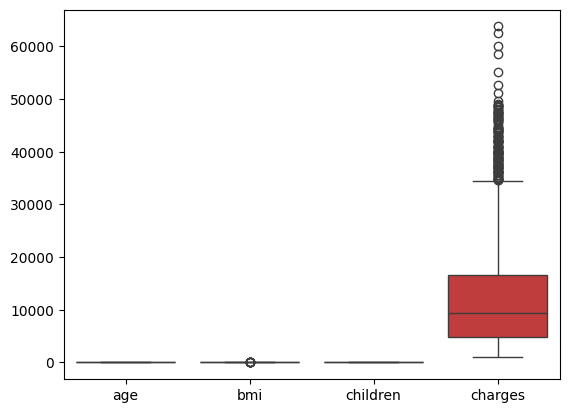

In [ ]:
sns.boxplot(data = df)
plt.show()

## Step 2: Exploratory Data Analysis (EDA)
Visualizing the features using a boxplot to inspect outliers, and a pairplot to understand distributions and relationships based on smoker status.

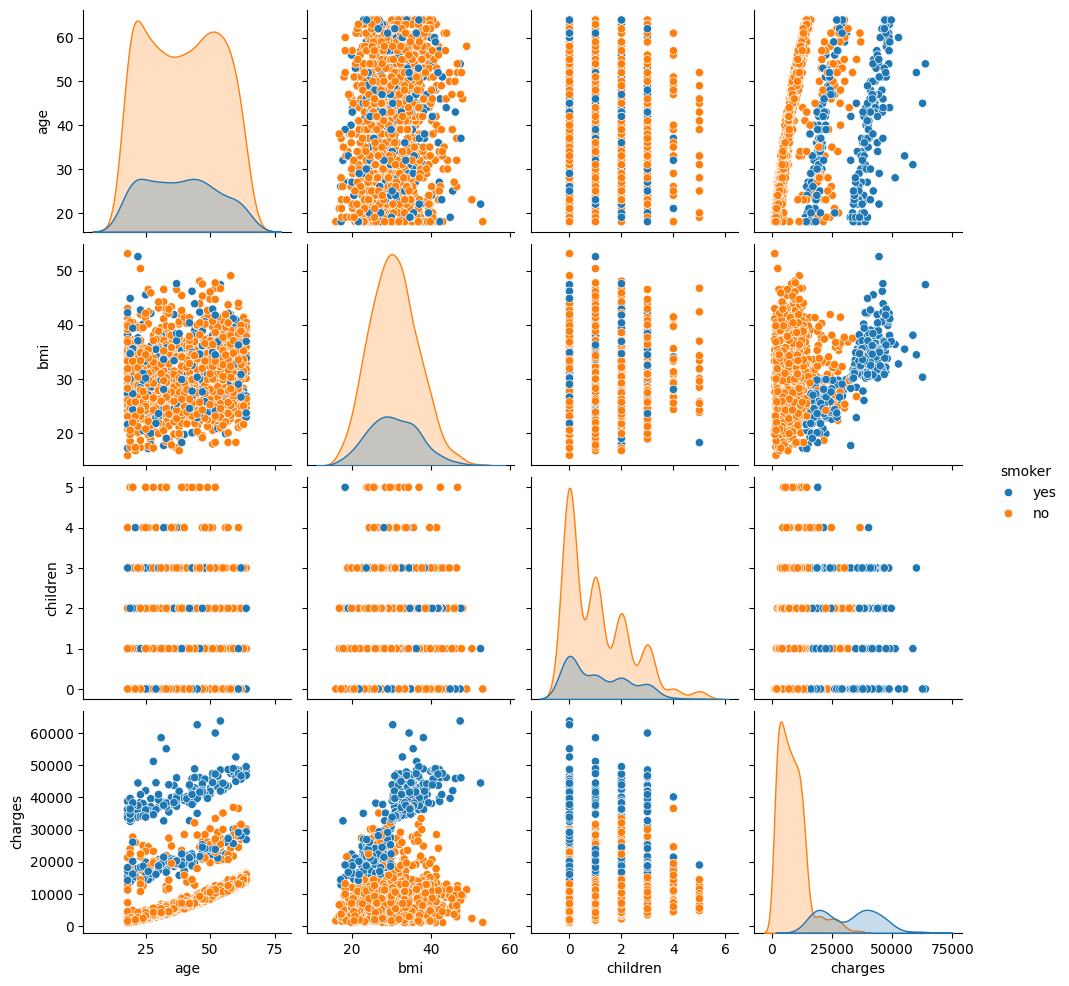

In [ ]:
sns.pairplot(df, hue='smoker')
plt.show()

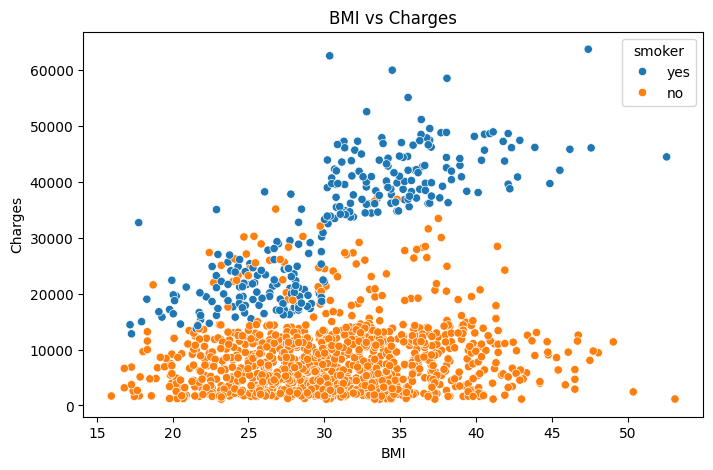

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

## Step 3: Feature Engineering & Data Splitting
Converting categorical variables to numerical using One-Hot Encoding, splitting the data into 80% training and 20% testing, and scaling the numerical features.

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)


## Step 4: Model Training, Regularization & Evaluation
Training a baseline Linear Regression, applying Ridge Regularization (alpha=1.0) to prevent overfitting, validating with 5-Fold Cross-Validation, and printing the final performance metrics (MSE and R-squared).

In [ ]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_scores = cross_val_score(ridge_model, X_train, y_train, cv = kf, scoring = 'r2')

print(f"Cross-Validation: {ridge_scores}")
print(f"Average cross-verification performance: {ridge_scores.mean():.4f}")

y_pred = ridge_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Cross-Validation: [0.72902227 0.71503579 0.77207694 0.68904511 0.70886141]
Average cross-verification performance: 0.7228
Mean Squared Error: 35663190.9847908
R-squared Score: 0.8059210117995655
